In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import regularizers

##Load MNIST Dat

In [4]:
mnist= keras.datasets.mnist # 28*28 images of hand-written digits 0-9

(x_train,y_train), (x_test,y_test) = mnist.load_data() #Unpack data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
#Unpack data
print(f"Shape of MNISt train set: {x_train.shape}")
print(f"Shape of MNISt train set: {x_test.shape}")

Shape of MNISt train set: (60000, 28, 28)
Shape of MNISt train set: (10000, 28, 28)


Label of  x_train[0] is : 5


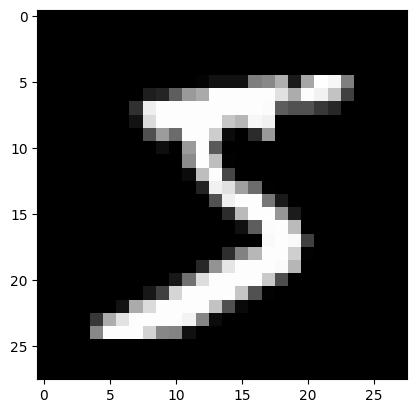

In [6]:
plt.imshow(x_train[0],cmap='gray')
print(f"Label of  x_train[0] is : {y_train[0]}")

In [7]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

##Normalize Data

In [8]:
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test,axis=1)

In [9]:
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

# Create Model

In [10]:
model=keras.models.Sequential()
model.add(keras.layers.Flatten()) #input layer
model.add(keras.layers.Dense(128,activation=tf.nn.relu,kernel_regularizer=regularizers.l1)) #first hidden layer
model.add(keras.layers.Dense(128,activation=tf.nn.relu,kernel_regularizer=regularizers.l2)) #second hidden layer
model.add(keras.layers.Dense(10,activation=tf.nn.softmax)) #output layer

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Train the model

In [12]:
model.fit(x_train,y_train,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5999 - loss: 5.0069
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8362 - loss: 1.1645
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8520 - loss: 1.0588


##Evaluate Model on Validation data

In [13]:
val_loss, val_acc=model.evaluate(x_test,y_test)
print(f"validation loss : {val_loss} \n validation_accuracy : {val_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8420 - loss: 1.0456
validation loss : 0.9955177903175354 
 validation_accuracy : 0.8585000038146973


##Autmatic Neural Network Hyperparameter Tuning Using Keras Tuner

In [14]:
!pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 1.8 MB/s eta 0:00:00


In [15]:
def model_builder(hp):
  model=keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28,28)))

  hp_activation = hp.Choice('activation',values=['relu','tanh'])
  hp_layer_1 = hp.Int('layer_1',min_value=64, max_value=256, step=64)
  hp_layer_2 = hp.Int('layer_2',min_value=64, max_value=256, step=64)
  hp_learning_rate=hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  model.add(keras.layers.Dense(units=hp_layer_1,activation=hp_activation))
  model.add(keras.layers.Dense(units=hp_layer_2,activation=hp_activation))
  model.add(keras.layers.Dense(10,activation='softmax'))

  model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [19]:
import keras_tuner as kt

tuner=kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=5,
                     factor=3,
                     directory='mnist_tuning',
                     project_name='mnist')

Reloading Tuner from mnist_tuning/mnist/tuner0.json


In [20]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

In [21]:
tuner.search(x_train,y_train,epochs=5,validation_split=0.2,callbacks=[stop_early])

Trial 30 Complete [00h 00m 44s]
val_accuracy: 0.9729999899864197

Best val_accuracy So Far: 0.9759166836738586
Total elapsed time: 00h 15m 22s


In [24]:
tuner.results_summary()


Results summary
Results in mnist_tuning/mnist
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0024 summary
Hyperparameters:
activation: relu
layer_1: 192
layer_2: 192
learning_rate: 0.001
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0023
Score: 0.9759166836738586

Trial 0016 summary
Hyperparameters:
activation: relu
layer_1: 128
layer_2: 64
learning_rate: 0.001
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 0.9745833277702332

Trial 0025 summary
Hyperparameters:
activation: relu
layer_1: 64
layer_2: 192
learning_rate: 0.001
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0018
Score: 0.9738333225250244

Trial 0029 summary
Hyperparameters:
activation: relu
layer_1: 64
layer_2: 128
learning_rate: 0.001
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9729999899864197

Trial 0023 summary
Hyperpa

In [25]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameters
print(f"Best activation function: {best_hps.get('activation')}")
print(f"Best layer 1 units: {best_hps.get('layer_1')}")
print(f"Best layer 2 units: {best_hps.get('layer_2')}")
print(f"Best learning rate: {best_hps.get('learning_rate')}")


Best activation function: relu
Best layer 1 units: 192
Best layer 2 units: 192
Best learning rate: 0.001


In [30]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
model = tuner.hypermodel.build(best_hps)



In [34]:
eval_result = model.evaluate(x_test, y_test)
print("[test loss, test accuracy]:", eval_result)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1122 - loss: 2.3075
[test loss, test accuracy]: [2.3063805103302, 0.12210000306367874]
